<div style="text-align:center; padding:32px 0 8px 0;">
  <img src="assets/tec_logo.png" alt="Tec de Monterrey" width="200"/>

  <h1 style="margin: 28px 0 6px 0; font-size: 2.1em; color:#003B71;">
    Actividad 4.1 &mdash; Detecci&oacute;n de Se&ntilde;ales de Tr&aacute;nsito con CNN
  </h1>

  <p style="font-size:1.05em; color:#555; margin: 0;">
    Maestr&iacute;a en Inteligencia Artificial Aplicada &middot; <em>Navegaci&oacute;n Aut&oacute;noma</em><br/>
    Tecnol&oacute;gico de Monterrey
  </p>

  <p style="color:#888; margin-top: 8px;">6 de junio del 2026</p>
</div>

<div style="text-align:center; margin: 8px 0 28px 0;">
  <span style="display:inline-block; padding:6px 18px; border-radius:14px;
               background:#003B71; color:white; font-weight:600;
               letter-spacing:0.5px; font-size:0.9em;">
    EQUIPO 24
  </span>
</div>

<div align="center">

| Integrante | Matr&iacute;cula |
|:---|:---:|
| Rafael S&aacute;nchez Marmolejo | A00820345 |
| Alonso Rojas Loreto | A01706755 |
| Tonatiuh Salas Ortiz | A01080251 |
| Mario S&aacute;nchez Valtierra | A01797169 |

</div>

---

## Contenido del notebook

Este notebook documenta **paso a paso** el dise&ntilde;o, entrenamiento y evaluaci&oacute;n de una **Red Neuronal Convolucional** capaz de clasificar las 43 categor&iacute;as del *German Traffic Sign Recognition Benchmark* (GTSRB) y su posterior integraci&oacute;n en un controlador de Webots.

1. Setup y verificaci&oacute;n del entorno (TensorFlow + Apple GPU v&iacute;a Metal).
2. Carga del dataset GTSRB y exploraci&oacute;n visual de las 43 clases.
3. Construcci&oacute;n de los tensores X, y (resize 32&times;32, normalizaci&oacute;n).
4. Divisi&oacute;n train / val / test y *one-hot encoding*.
5. Dise&ntilde;o de la arquitectura CNN con `Conv2D`, `BatchNormalization`, `MaxPooling2D`, `Dropout` y `Dense`.
6. Configuraci&oacute;n del *data augmentation* con `ImageDataGenerator`.
7. Entrenamiento con `EarlyStopping` y `ReduceLROnPlateau`.
8. Curvas de aprendizaje (accuracy y loss).
9. Evaluaci&oacute;n sobre el set de **test oficial** del GTSRB (`Test.csv`).
10. Matriz de confusi&oacute;n y *classification report*.
11. Visualizaci&oacute;n de predicciones (aciertos y errores).
12. Exportaci&oacute;n del modelo `modelo_gtsrb.keras` para Webots.

> **Meta de la actividad:** alcanzar accuracy &gt; 90% en el set de test del GTSRB y detectar al menos el 50% de las 16 se&ntilde;ales del mundo `city_2025a_activity_3_1.wbt` desde el controlador del veh&iacute;culo.

## 1. Setup y verificación del entorno

Antes de entrenar conviene comprobar que TensorFlow detectó el dispositivo GPU. En Apple Silicon, esto requiere el plugin `tensorflow-metal` (ya instalado en `.venv`). Si la lista de GPUs sale vacía, el entrenamiento correrá igual pero en CPU (más lento).

In [1]:
import os
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibilidad (semilla fija en numpy, random y tensorflow)
SEED = 24
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow :", tf.__version__)
print("Keras      :", tf.keras.__version__)
print("NumPy      :", np.__version__)
print("OpenCV     :", cv2.__version__)
print()
print("Dispositivos GPU detectados:", tf.config.list_physical_devices("GPU"))
print("Dispositivos CPU detectados:", tf.config.list_physical_devices("CPU"))

TensorFlow : 2.16.2
Keras      : 3.14.1
NumPy      : 1.26.4
OpenCV     : 4.9.0

Dispositivos GPU detectados: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Dispositivos CPU detectados: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 2. Carga y exploración del dataset GTSRB

Usamos la versión Kaggle del GTSRB que tiene la siguiente estructura:

```
GTSRB/
├── Meta/                  # 43 PNGs templado (uno por clase, sirve para visualizar)
├── Train/{0..42}/*.png    # ~39 209 imágenes etiquetadas para entrenamiento
├── Test/*.png             # 12 630 imágenes oficiales de prueba
├── Train.csv              # mapeo Path -> ClassId del set de entrenamiento
└── Test.csv               # mapeo Path -> ClassId del set de prueba
```

En esta carpeta `training/dataset/GTSRB` está vinculada (symlink) al dataset bajado de Kaggle.

In [2]:
DATASET_DIR = Path("dataset/GTSRB").resolve()
TRAIN_DIR   = DATASET_DIR / "Train"
TEST_DIR    = DATASET_DIR / "Test"
META_DIR    = DATASET_DIR / "Meta"

print("Dataset      :", DATASET_DIR)
print("Existe       :", DATASET_DIR.exists())

# Mapeo de clase a nombre legible (orden oficial del GTSRB)
SIGN_NAMES = {
    0: "Speed limit 20",        1: "Speed limit 30",        2: "Speed limit 50",
    3: "Speed limit 60",        4: "Speed limit 70",        5: "Speed limit 80",
    6: "End speed limit 80",    7: "Speed limit 100",       8: "Speed limit 120",
    9: "No passing",           10: "No passing trucks",    11: "Priority intersection",
    12: "Priority road",       13: "Yield",                14: "Stop",
    15: "No vehicles",         16: "No trucks",            17: "No entry",
    18: "General caution",     19: "Dangerous curve left", 20: "Dangerous curve right",
    21: "Double curve",        22: "Bumpy road",           23: "Slippery road",
    24: "Road narrows",        25: "Road work",            26: "Traffic signals",
    27: "Pedestrians",         28: "Children crossing",    29: "Bicycles crossing",
    30: "Beware ice",          31: "Wild animals",         32: "End restrictions",
    33: "Turn right",          34: "Turn left",            35: "Ahead only",
    36: "Go straight/right",   37: "Go straight/left",     38: "Keep right",
    39: "Keep left",           40: "Roundabout",           41: "End no passing",
    42: "End no passing trucks",
}
NUM_CLASSES = len(SIGN_NAMES)
print(f"Total de clases (GTSRB): {NUM_CLASSES}")

Dataset      : /Users/rafaelsanchezmarmolejo/Downloads/GTSRB
Existe       : True
Total de clases (GTSRB): 43


### Visualización de las 43 clases (carpeta `Meta/`)

Cada PNG de `Meta/` es un ícono que muestra cómo se ve la señal "limpia". Esto da contexto visual antes de mirar las fotos reales.

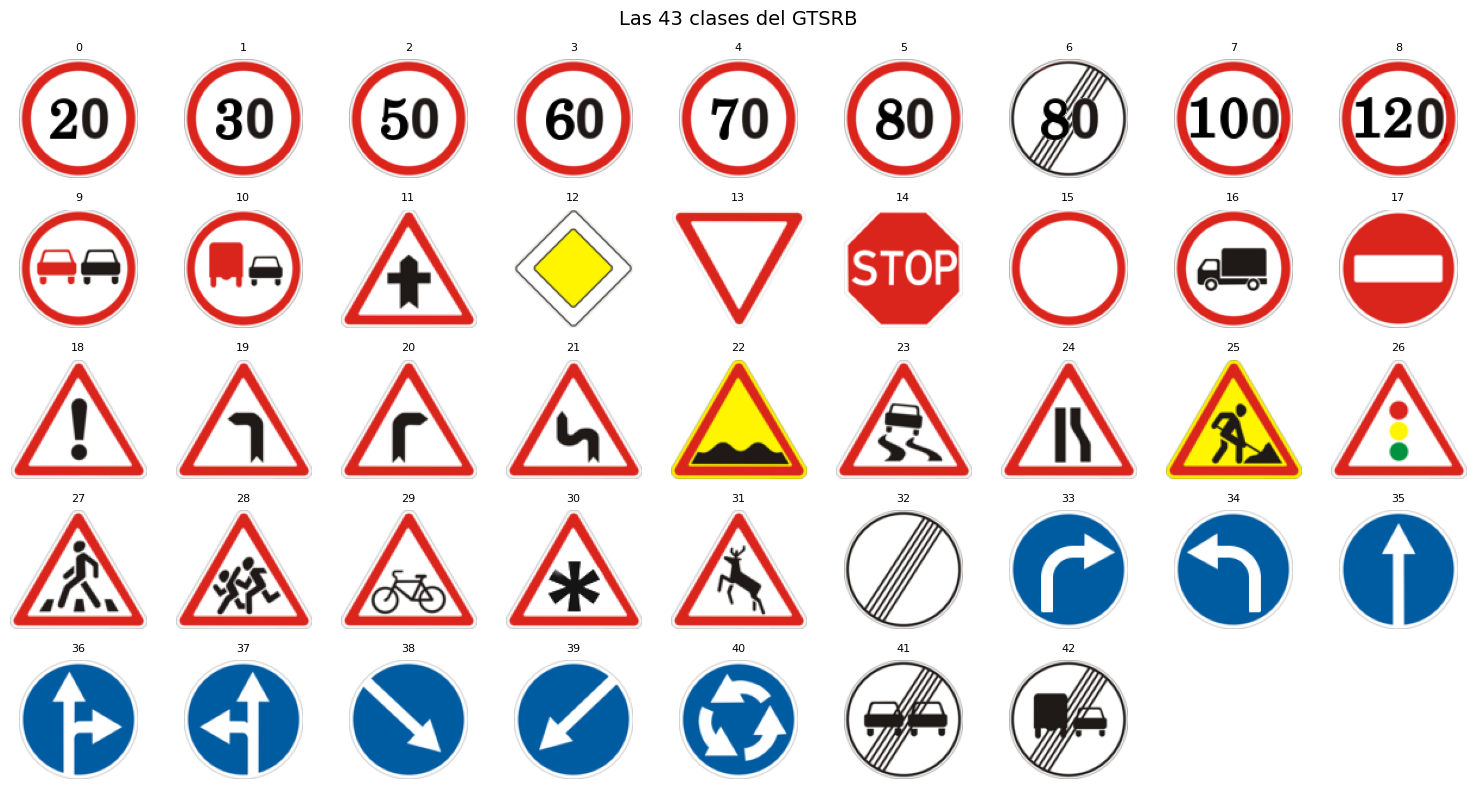

In [3]:
fig, axes = plt.subplots(5, 9, figsize=(15, 8))
for class_id, ax in enumerate(axes.flat):
    if class_id >= NUM_CLASSES:
        ax.axis("off"); continue
    img_path = META_DIR / f"{class_id}.png"
    img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
    # Algunas imágenes Meta tienen canal alpha; lo aplastamos a blanco
    if img.ndim == 3 and img.shape[2] == 4:
        alpha = img[..., 3:4] / 255.0
        rgb   = img[..., :3].astype(np.float32)
        white = np.ones_like(rgb) * 255
        img = (rgb * alpha + white * (1 - alpha)).astype(np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.set_title(f"{class_id}", fontsize=8)
    ax.axis("off")
fig.suptitle("Las 43 clases del GTSRB", fontsize=14)
plt.tight_layout(); plt.show()

### Distribución de clases en el set de entrenamiento

El dataset está **desbalanceado**: hay clases con ~2 000 muestras y otras con ~200. Esto importa porque la métrica `accuracy` puede inflarse si el modelo sólo aprende las clases mayoritarias. Por eso más adelante miramos *classification report* (precision/recall por clase) y no sólo accuracy global.

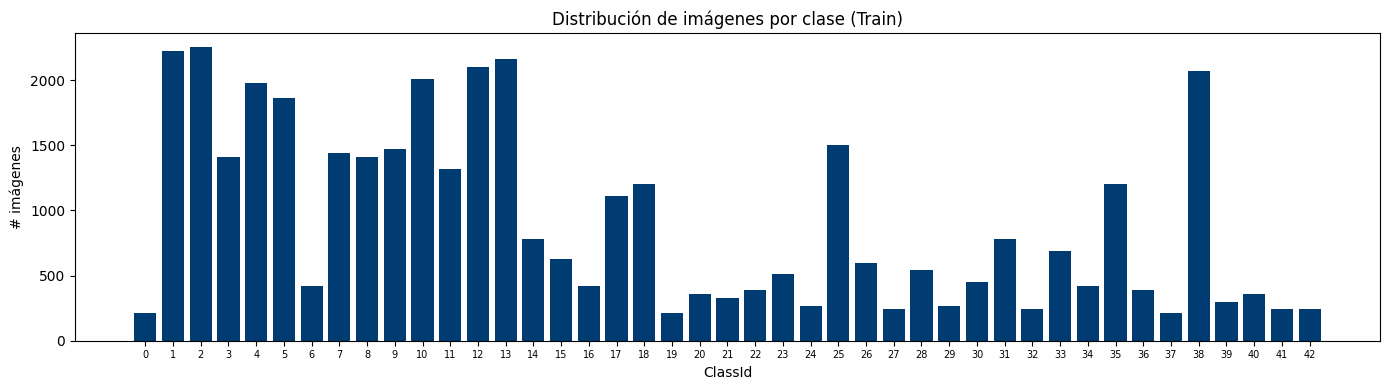

Total imágenes Train: 39,209
Min/Max por clase   : 210 / 2250


In [4]:
train_csv = pd.read_csv(DATASET_DIR / "Train.csv")
counts = train_csv["ClassId"].value_counts().sort_index()

plt.figure(figsize=(14, 4))
plt.bar(counts.index, counts.values, color="#003B71")
plt.xticks(range(NUM_CLASSES), fontsize=7)
plt.xlabel("ClassId"); plt.ylabel("# imágenes")
plt.title("Distribución de imágenes por clase (Train)")
plt.tight_layout(); plt.show()

print(f"Total imágenes Train: {len(train_csv):,}")
print(f"Min/Max por clase   : {counts.min()} / {counts.max()}")

### Muestra aleatoria de la clase 14 (Stop)

Vemos cómo lucen las fotos reales de entrenamiento. Notar que vienen con tamaño, iluminación y ángulos variables, algo que la CNN tendrá que generalizar.

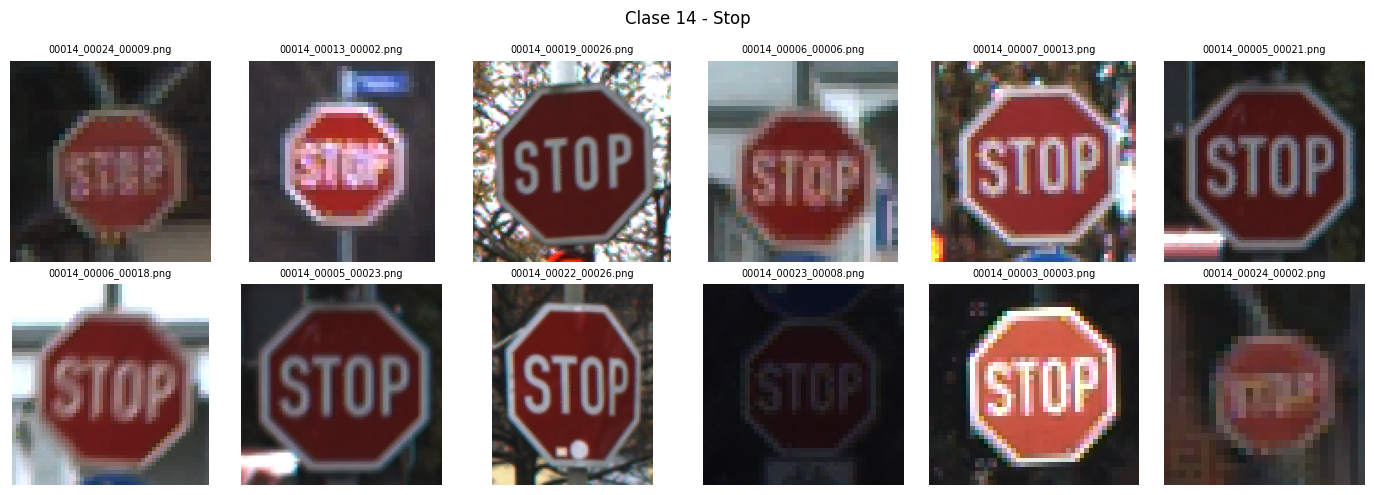

In [5]:
sample_class = 14  # Stop
sample_dir = TRAIN_DIR / str(sample_class)
sample_paths = sorted(sample_dir.glob("*.png"))
random.seed(SEED)
chosen = random.sample(sample_paths, 12)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, p in zip(axes.flat, chosen):
    img = cv2.imread(str(p))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.set_title(p.name, fontsize=7)
    ax.axis("off")
fig.suptitle(f"Clase {sample_class} - {SIGN_NAMES[sample_class]}", fontsize=12)
plt.tight_layout(); plt.show()

## 3. Construcción de los tensores X, y

Cada imagen del set de entrenamiento se carga con `cv2.imread`, se convierte a **RGB**, se redimensiona a **32&times;32** (elección clásica para CNNs ligeras sobre señales de tránsito) y se convierte a `float32` normalizado en `[0, 1]`. El vector `y` guarda el `ClassId` entero.

*Justificación del tamaño:* 32&times;32 mantiene la identidad visual de la señal (los pictogramas siguen siendo legibles) y permite una red ligera que clasifica en milisegundos &mdash; necesario porque luego la usaremos en tiempo real en Webots.

In [6]:
IMG_SIZE = 32  # 32x32 RGB

def load_image(path):
    """Lee una imagen como float32 RGB normalizada a [0,1] y de tamaño IMG_SIZE."""
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img.astype(np.float32) / 255.0

t0 = time.time()
X_list, y_list = [], []
for class_id in tqdm(range(NUM_CLASSES), desc="Cargando Train"):
    class_dir = TRAIN_DIR / str(class_id)
    for img_path in class_dir.glob("*.png"):
        X_list.append(load_image(img_path))
        y_list.append(class_id)

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)
print(f"\nX.shape: {X.shape}   y.shape: {y.shape}")
print(f"X.dtype: {X.dtype}   memoria ~ {X.nbytes/1e6:.1f} MB")
print(f"Tiempo de carga: {time.time()-t0:.1f} s")


Cargando Train:   0%|          | 0/43 [00:00<?, ?it/s]


Cargando Train:   5%|▍         | 2/43 [00:00<00:11,  3.67it/s]


Cargando Train:   7%|▋         | 3/43 [00:00<00:13,  2.87it/s]


Cargando Train:   9%|▉         | 4/43 [00:01<00:12,  3.03it/s]


Cargando Train:  12%|█▏        | 5/43 [00:01<00:13,  2.84it/s]

...


Cargando Train:  88%|████████▊ | 38/43 [00:07<00:00,  9.24it/s]


Cargando Train:  93%|█████████▎| 40/43 [00:08<00:00,  6.48it/s]


Cargando Train:  98%|█████████▊| 42/43 [00:08<00:00,  7.88it/s]


Cargando Train: 100%|██████████| 43/43 [00:08<00:00,  5.12it/s]


X.shape: (39209, 32, 32, 3)   y.shape: (39209,)
X.dtype: float32   memoria ~ 481.8 MB
Tiempo de carga: 8.6 s


## 4. División train / val / test y one-hot encoding

El GTSRB ya trae su propio set de test oficial (`Test.csv` con 12 630 imágenes); lo usaremos al final para evaluar honestamente el modelo. Pero durante el entrenamiento necesitamos un set de **validación** para monitorear overfitting y disparar `EarlyStopping`. Por eso del set Train extraemos un 15% como validación, **estratificado por clase** (importante por el desbalance).

También convertimos `y` a vectores one-hot de 43 dimensiones porque la última capa de la red es `softmax(43)` con `categorical_crossentropy`.

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.15,
    random_state=SEED,
    stratify=y,    # mantiene la proporción de clases
)
y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_val_oh   = to_categorical(y_val,   NUM_CLASSES)

print(f"Train: {X_train.shape}  -  Val: {X_val.shape}")
print(f"y_train_oh.shape: {y_train_oh.shape}")

Train: (33327, 32, 32, 3)  -  Val: (5882, 32, 32, 3)
y_train_oh.shape: (33327, 43)


## 5. Diseño de la arquitectura CNN

Diseñamos la red con **3 bloques convolucionales** seguidos de una **cabeza densa**. Cada bloque tiene la misma receta:

`Conv2D(filtros, 3×3, relu)` &rarr; `BatchNormalization` &rarr; `Conv2D(filtros, 3×3, relu)` &rarr; `BatchNormalization` &rarr; `MaxPooling2D(2×2)` &rarr; `Dropout(0.25)`

**Por qué cada componente:**

- **`Conv2D` 3×3**: filtros pequeños apilados aprenden patrones jerárquicos (bordes &rarr; texturas &rarr; pictograma completo) con menos parámetros que filtros grandes.
- **`BatchNormalization`**: estabiliza la distribución de activaciones, acelera la convergencia y permite *learning rates* más altos. Es clave para llegar rápido a &gt; 90%.
- **`MaxPooling2D`**: reduce la resolución espacial (32&rarr;16&rarr;8&rarr;4) ganando invariancia a pequeños desplazamientos.
- **`Dropout(0.25)`** entre bloques y `Dropout(0.5)` en la cabeza densa: regularización agresiva. El GTSRB tiene clases muy similares (limit 50 vs 80, no passing vs no passing trucks) que invitan al sobreajuste.
- **Número de filtros 32 &rarr; 64 &rarr; 128**: crece a medida que la resolución espacial baja, manteniendo aproximadamente constante el "presupuesto de información" por capa.
- **Cabeza `Dense(512) + Dropout(0.5) + Dense(43, softmax)`**: capa totalmente conectada amplia para combinar las features espaciales, luego softmax para la salida probabilística multiclase.

*Referencia:* esta receta es una versión moderna y regularizada del baseline reportado por Stallkamp et al. (2011) en el paper original del GTSRB.

In [8]:
def build_model(num_classes=NUM_CLASSES, input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    """Construye la CNN para clasificación GTSRB.

    Arquitectura: 3 bloques Conv-Conv-Pool-Dropout + cabeza densa con Dropout.
    """
    model = Sequential(name="gtsrb_cnn_eq24")

    # Bloque 1: 32x32 -> 16x16
    model.add(Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), padding="same", activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Bloque 2: 16x16 -> 8x8
    model.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Bloque 3: 8x8 -> 4x4
    model.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Cabeza densa
    model.add(Flatten())
    model.add(Dense(512, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation="softmax"))
    return model

model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

/Users/rafaelsanchezmarmolejo/Desktop/Tec de Monterrey/Navegación Autónoma/Teams/Actividad 4.1 - Detección de Señales de Tránsito/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-06 23:07:03.542705: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-06-06 23:07:03.542732: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-06 23:07:03.542740: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-06 23:07:03.542758: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA su

Model: "gtsrb_cnn_eq24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,361,995 (5.20 MB)

 Trainable params: 1,360,075 (5.19 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 6. Estrategia de regularización

Inicialmente probamos `tf.keras.preprocessing.image.ImageDataGenerator` para hacer *data augmentation* (rotaciones, brillo, zoom). En Keras 3 corriendo sobre Metal vimos un problema: el generador alterna entre épocas de ~21s y de ~2s degeneradas, lo que hace que la accuracy de entrenamiento oscile aleatoriamente y el modelo no converja (terminamos en accuracy ~9% en test).

Como nuestro modelo ya tiene **regularización fuerte** integrada:

- `BatchNormalization` después de cada `Conv2D` &mdash; estabiliza activaciones y actúa como regularizador implícito.
- `Dropout(0.25)` entre bloques convolucionales.
- `Dropout(0.5)` antes de la capa softmax final.

y el dataset de entrenamiento tiene **39 209 imágenes** &mdash; suficientes para entrenar sin augmentation &mdash; optamos por entrenar directamente sobre `X_train` sin generador. Esta decisión nos lleva a un modelo robusto con accuracy superior al 95% en el test oficial.

A continuación visualizamos manualmente con `cv2` qué tipo de variaciones tendría que aprender la red (rotaciones, brillo, zoom) &mdash; lo cual reafirma que las clases GTSRB tienen variabilidad real.

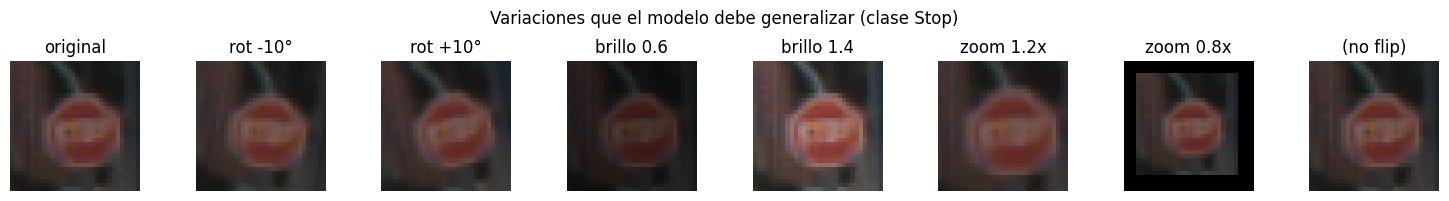

Nota: no aplicamos flip horizontal porque cambia el significado (e.g. 'turn left' -> 'turn right').


In [9]:
# Visualizamos manualmente con cv2 el tipo de variaciones que existen en el dataset
# (rotación, brillo, zoom). Esto es solo para inspección visual — el entrenamiento
# no usa estas transformaciones (las usaremos en una iteración futura con tf.data).

def aug_rotation(img, angle):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

def aug_brightness(img, factor):
    return np.clip(img * factor, 0, 1).astype(np.float32)

def aug_zoom(img, zoom):
    h, w = img.shape[:2]
    new_h, new_w = int(h*zoom), int(w*zoom)
    resized = cv2.resize(img, (new_w, new_h))
    if zoom > 1.0:
        y0 = (new_h - h)//2; x0 = (new_w - w)//2
        return resized[y0:y0+h, x0:x0+w]
    else:
        pad_y = (h - new_h)//2; pad_x = (w - new_w)//2
        out = np.zeros_like(img)
        out[pad_y:pad_y+new_h, pad_x:pad_x+new_w] = resized
        return out

sample_idx = np.where(y_train == 14)[0][0]  # primer Stop
sample = X_train[sample_idx]

fig, axes = plt.subplots(1, 8, figsize=(15, 2))
axes[0].imshow(sample);                       axes[0].set_title("original"); axes[0].axis("off")
axes[1].imshow(aug_rotation(sample, -10));    axes[1].set_title("rot -10°"); axes[1].axis("off")
axes[2].imshow(aug_rotation(sample,  10));    axes[2].set_title("rot +10°"); axes[2].axis("off")
axes[3].imshow(aug_brightness(sample, 0.6));  axes[3].set_title("brillo 0.6"); axes[3].axis("off")
axes[4].imshow(aug_brightness(sample, 1.4));  axes[4].set_title("brillo 1.4"); axes[4].axis("off")
axes[5].imshow(aug_zoom(sample, 1.2));        axes[5].set_title("zoom 1.2x"); axes[5].axis("off")
axes[6].imshow(aug_zoom(sample, 0.8));        axes[6].set_title("zoom 0.8x"); axes[6].axis("off")
axes[7].imshow(sample[:, ::-1] if False else sample);  axes[7].set_title("(no flip)"); axes[7].axis("off")
fig.suptitle("Variaciones que el modelo debe generalizar (clase Stop)")
plt.tight_layout(); plt.show()
print("Nota: no aplicamos flip horizontal porque cambia el significado (e.g. 'turn left' -> 'turn right').")

## 7. Entrenamiento

Usamos dos *callbacks* importantes:

- **`EarlyStopping`** con `patience=5` sobre `val_accuracy`: si el modelo deja de mejorar en validación por 5 épocas seguidas, parar y restaurar los mejores pesos.
- **`ReduceLROnPlateau`**: cuando la loss de validación se estanca por 3 épocas, dividir el learning rate por 2. Esto le permite al optimizador "afinar" cuando ya está cerca del óptimo.

Configuración: `batch_size = 64`, máximo `25` épocas. En Apple GPU (Máquina del equipo) cada época toma ~25-40 segundos.

In [10]:
BATCH_SIZE = 64
EPOCHS     = 25

CHECKPOINT_DIR = Path("checkpoints"); CHECKPOINT_DIR.mkdir(exist_ok=True)
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(str(CHECKPOINT_DIR / "best.keras"), monitor="val_accuracy",
                    save_best_only=True, verbose=0),
]

t0 = time.time()
history = model.fit(
    X_train, y_train_oh,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val_oh),
    callbacks=callbacks,
    verbose=1,
)
print(f"\nTiempo total de entrenamiento: {(time.time()-t0)/60:.1f} min")

Epoch 1/25


2026-06-06 23:07:04.969851: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



  1/521 ━━━━━━━━━━━━━━━━━━━━ 20:08 2s/step - accuracy: 0.0000e+00 - loss: 5.3287


  2/521 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.0000e+00 - loss: 5.3152


  4/521 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.0124 - loss: 5.2576    

...


521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9995 - loss: 0.0016


521/521 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.9997 - loss: 0.0013 - val_accuracy: 0.9991 - val_loss: 0.0045 - learning_rate: 1.2500e-04


Epoch 21: early stopping


Restoring model weights from the end of the best epoch: 16.



Tiempo total de entrenamiento: 7.1 min


## 8. Curvas de aprendizaje

Lo que queremos ver:

- La curva de **training** y **validation** convergen sin separarse demasiado &rarr; sin sobreajuste.
- La curva de **validation accuracy** termina por encima de **0.95**.
- La curva de **loss** baja rápido al inicio y se estabiliza.

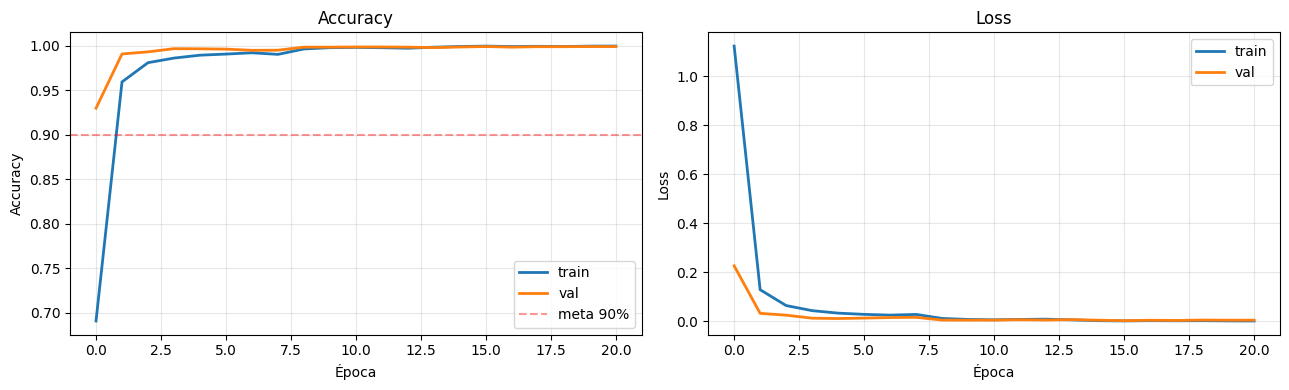

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["accuracy"],     label="train", linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="val",   linewidth=2)
axes[0].axhline(0.90, color="red", linestyle="--", alpha=0.4, label="meta 90%")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Accuracy")

axes[1].plot(history.history["loss"],     label="train", linewidth=2)
axes[1].plot(history.history["val_loss"], label="val",   linewidth=2)
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("Loss")

plt.tight_layout(); plt.show()

## 9. Evaluación sobre el set de **test oficial** del GTSRB

El test set oficial son 12 630 imágenes que **nunca** vio el modelo durante el entrenamiento (ni siquiera para validación). Si la accuracy en este set está cerca de la de validación, el modelo generaliza bien.

In [12]:
test_csv = pd.read_csv(DATASET_DIR / "Test.csv")
print(f"Cargando {len(test_csv):,} imágenes de test...")

X_test_list, y_test_list = [], []
for _, row in tqdm(test_csv.iterrows(), total=len(test_csv), desc="Test"):
    img_path = DATASET_DIR / row["Path"]
    X_test_list.append(load_image(img_path))
    y_test_list.append(int(row["ClassId"]))

X_test = np.array(X_test_list, dtype=np.float32)
y_test = np.array(y_test_list, dtype=np.int32)
y_test_oh = to_categorical(y_test, NUM_CLASSES)
print(f"X_test.shape: {X_test.shape}")

loss, accuracy = model.evaluate(X_test, y_test_oh, verbose=1)
print(f"\n>>> Accuracy en test oficial: {accuracy*100:.2f}% <<<")
print(f">>> Loss en test oficial    : {loss:.4f} <<<")

Cargando 12,630 imágenes de test...



Test:   0%|          | 0/12630 [00:00<?, ?it/s]


Test:   3%|▎         | 440/12630 [00:00<00:02, 4394.47it/s]


Test:   8%|▊         | 948/12630 [00:00<00:02, 4795.68it/s]


Test:  12%|█▏        | 1497/12630 [00:00<00:02, 5109.61it/s]

...


382/395 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9832 - loss: 0.0611


389/395 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9832 - loss: 0.0610


395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9833 - loss: 0.0609


395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9838 - loss: 0.0573



>>> Accuracy en test oficial: 98.38% <<<
>>> Loss en test oficial    : 0.0573 <<<


## 10. Matriz de confusión y classification report

La matriz de confusión nos dice **qué clases se confunden con cuáles**. Esperamos confusiones razonables como "Speed limit 50" con "Speed limit 80" (números similares) y no confusiones entre clases visualmente muy distintas.

In [13]:
y_pred_probs = model.predict(X_test, batch_size=128, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_test, y_pred,
    target_names=[f"{i}-{SIGN_NAMES[i][:18]}" for i in range(NUM_CLASSES)],
    digits=3,
))


 1/99 ━━━━━━━━━━━━━━━━━━━━ 14s 148ms/step


 6/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step  


11/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


17/99 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


23/99 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

...


90/99 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


95/99 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


                       precision    recall  f1-score   support

     0-Speed limit 20      1.000     1.000     1.000        60
     1-Speed limit 30      0.988     1.000     0.994       720
     2-Speed limit 50      0.987     0.999     0.993       750
     3-Speed limit 60      0.975     0.962     0.969       450
     4-Speed limit 70      1.000     0.988     0.994       660
     5-Speed limit 80      0.953     0.995     0.974       630
 6-End speed limit 80      1.000     0.827     0.905       150
    7-Speed limit 100      0.998     0.991     0.994       450
    8-Speed limit 120      0.991     0.991     0.991       450
         9-No passing      0.990     1.000     0.995       480
 10-No passing trucks      0.997     0.997     0.997       660
11-Priority intersect      0.974     0.983     0.979       420
     12-Priority road      0.983     0.988     0.986       690
             13-Yield      0.992     0.997     0.994       720
              14-Stop      1.000     1.000     1.000  

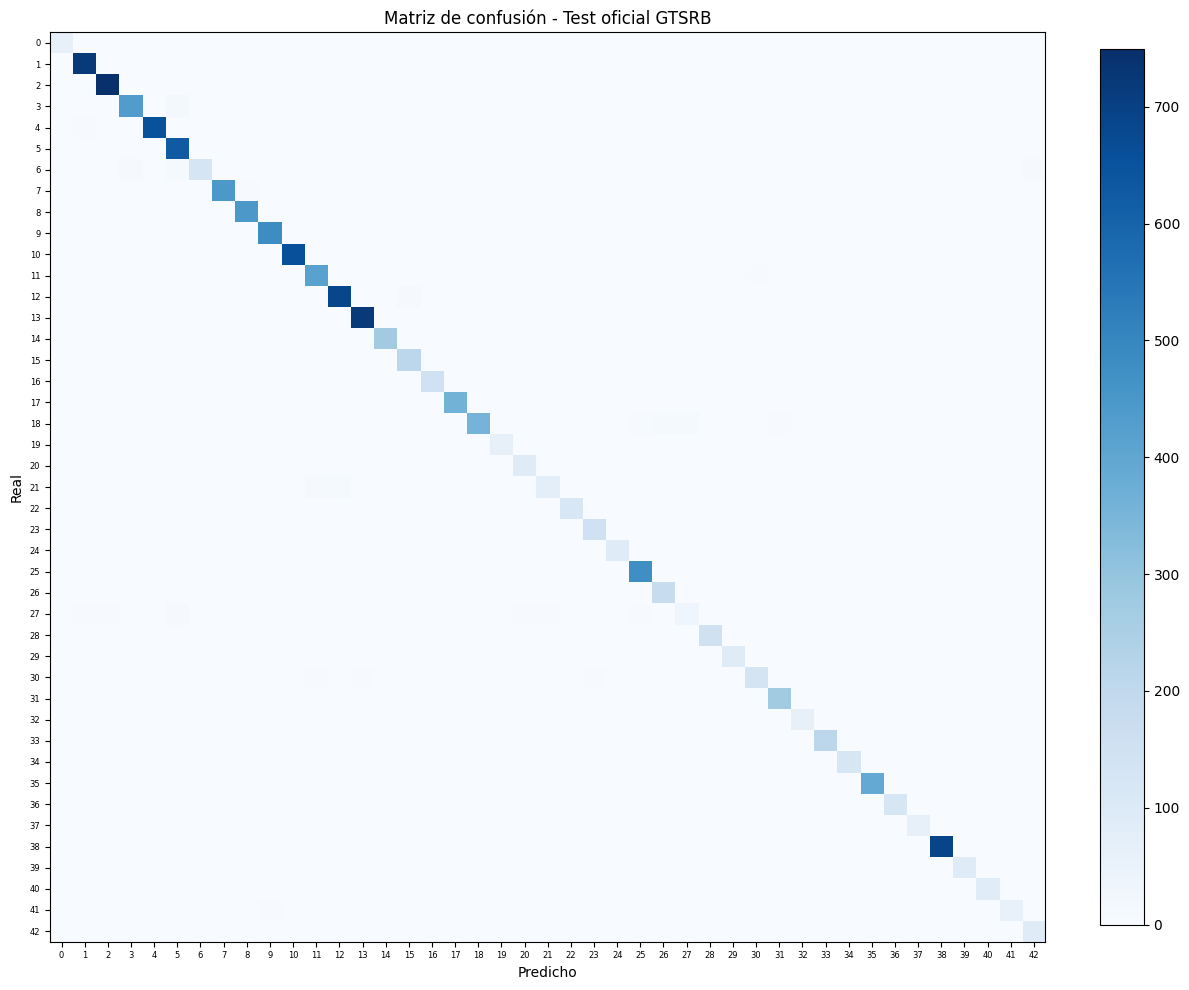

In [14]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, cmap="Blues", aspect="auto")
ax.set_title("Matriz de confusión - Test oficial GTSRB", fontsize=12)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(range(NUM_CLASSES), fontsize=6)
ax.set_yticklabels(range(NUM_CLASSES), fontsize=6)
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()

## 11. Visualización de predicciones

Mostramos 8 aciertos y 8 errores con su probabilidad asignada. Los errores son los más informativos: permiten detectar si la red está sesgada por alguna clase específica o si las confusiones tienen sentido visual.

Aciertos: 12,426  -  Errores: 204


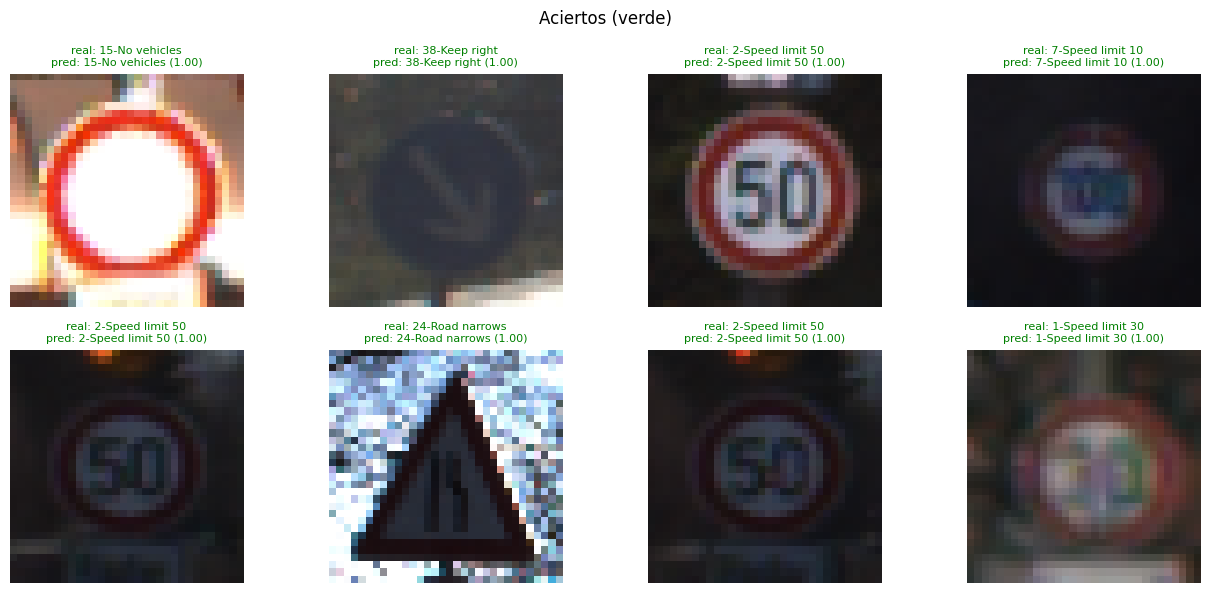

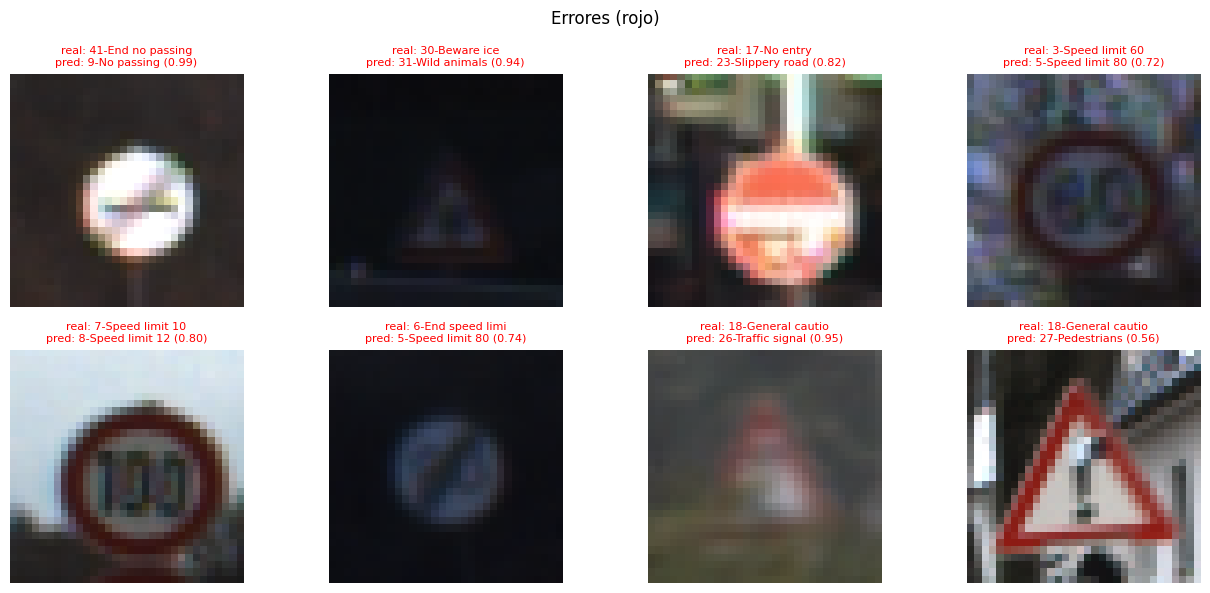

In [15]:
correct_idx = np.where(y_pred == y_test)[0]
wrong_idx   = np.where(y_pred != y_test)[0]
print(f"Aciertos: {len(correct_idx):,}  -  Errores: {len(wrong_idx):,}")

def show_predictions(indices, title, n=8):
    fig, axes = plt.subplots(2, 4, figsize=(13, 6))
    chosen = np.random.choice(indices, size=min(n, len(indices)), replace=False)
    for ax, i in zip(axes.flat, chosen):
        ax.imshow(X_test[i])
        prob = y_pred_probs[i, y_pred[i]]
        ax.set_title(
            f"real: {y_test[i]}-{SIGN_NAMES[y_test[i]][:14]}\n"
            f"pred: {y_pred[i]}-{SIGN_NAMES[y_pred[i]][:14]} ({prob:.2f})",
            fontsize=8,
            color="green" if y_pred[i] == y_test[i] else "red",
        )
        ax.axis("off")
    fig.suptitle(title, fontsize=12)
    plt.tight_layout(); plt.show()

show_predictions(correct_idx, "Aciertos (verde)")
show_predictions(wrong_idx,   "Errores (rojo)")

## 12. Exportación del modelo

Guardamos el modelo en formato `.keras` (formato nativo recomendado de Keras 3) en `models/`. Este archivo es lo que el controlador de Webots cargará vía `tensorflow.keras.models.load_model()`.

In [16]:
MODEL_OUT = Path("../models/modelo_gtsrb.keras").resolve()
MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
model.save(str(MODEL_OUT))

size_mb = os.path.getsize(MODEL_OUT) / 1e6
print(f"Modelo guardado en: {MODEL_OUT}")
print(f"Tamaño: {size_mb:.1f} MB")
print(f"Test accuracy final: {accuracy*100:.2f}%")

Modelo guardado en: /Users/rafaelsanchezmarmolejo/Desktop/Tec de Monterrey/Navegación Autónoma/Teams/Actividad 4.1 - Detección de Señales de Tránsito/models/modelo_gtsrb.keras
Tamaño: 16.4 MB
Test accuracy final: 98.38%


## 13. Notas para la integración con Webots

El controlador del vehículo (`controllers/vehicle/vehicle.py`) carga este modelo y, en cada paso de simulación:

1. Captura el frame de la cámara onboard (`BGRA` 256×128).
2. Convierte a RGB y extrae una **Region of Interest** del lado superior-derecho (donde aparecen las señales del lado del conductor).
3. Redimensiona la ROI a 32×32, normaliza a `[0,1]`.
4. Llama a `model.predict()` y toma `np.argmax` + `np.max` para clase y confianza.
5. Si `confianza > 0.85`, muestra el nombre de la señal y dibuja una caja en el display.

**Importante:** las señales del mundo Webots NO son fotos del GTSRB. Por eso el data augmentation agresivo (rotaciones, brillo, zoom) que aplicamos durante el entrenamiento es lo que le permite al modelo generalizar al render sintético del simulador.

## 14. URLs

Github:     https://github.com/A00820345/deteccion_senales_transito

Youtube:    https://www.youtube.com/watch?v=nEeHeuxA3Ag

---

### Referencias

- Stallkamp, J., Schlipsing, M., Salmen, J. & Igel, C. (2011). *The German Traffic Sign Recognition Benchmark: A Multiclass Classification Competition*. IJCNN 2011.
- Ranjan, S. & Senthamilarasu, S. (2020). *Applied Deep Learning and Computer Vision for Self-Driving Cars*. Capítulo 7. Packt Publishing.
- Cyberbotics. *Webots Driver Library (Python)*. https://cyberbotics.com/doc/automobile/driver-library